## Enhanced Plan:

1. **Data Loading & Initial Exploration**
   - Load train/test data
   - Basic info about datasets
   - Target variable analysis

2. **Comprehensive EDA**
   - Missing value analysis
   - Outlier detection
   - Feature distributions
   - Correlation analysis

3. **Feature Engineering**
   - Create derived features
   - Handle temporal features
   - Create interaction features

4. **Data Preprocessing**
   - Handle missing values (more sophisticated than simple imputation)
   - Encode categorical variables
   - Scale numerical features
   - Transform target variable

5. **Model Development**
   - Baseline XGBoost
   - Feature importance analysis
   - Hyperparameter tuning
   - Cross-validation

6. **Ensemble & Final Model**
   - Try multiple algorithms
   - Ensemble predictions
   - Final validation

7. **Prediction & Submission**
   - Predict on test set
   - Create submission file


In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv('train.csv')
df.isnull().sum()

df.drop(columns=['Id'], inplace=True)

df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [54]:
# check for missing values

print("\nMISSING VALUE ANALYSIS")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print("Missing values by column:")
print(missing_df[missing_df['Missing_Count'] > 0])


MISSING VALUE ANALYSIS
Missing values by column:
              Missing_Count  Missing_Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageYrBlt              81            5.547945
GarageCond               81            5.547945
GarageType               81            5.547945
GarageFinish             81            5.547945
GarageQual               81            5.547945
BsmtExposure             38            2.602740
BsmtFinType2             38            2.602740
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
BsmtFinType1             37            2.534247
MasVnrArea                8            0.547945
Electrical                1           

CORRELATION ANALYSIS
Top 15 correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


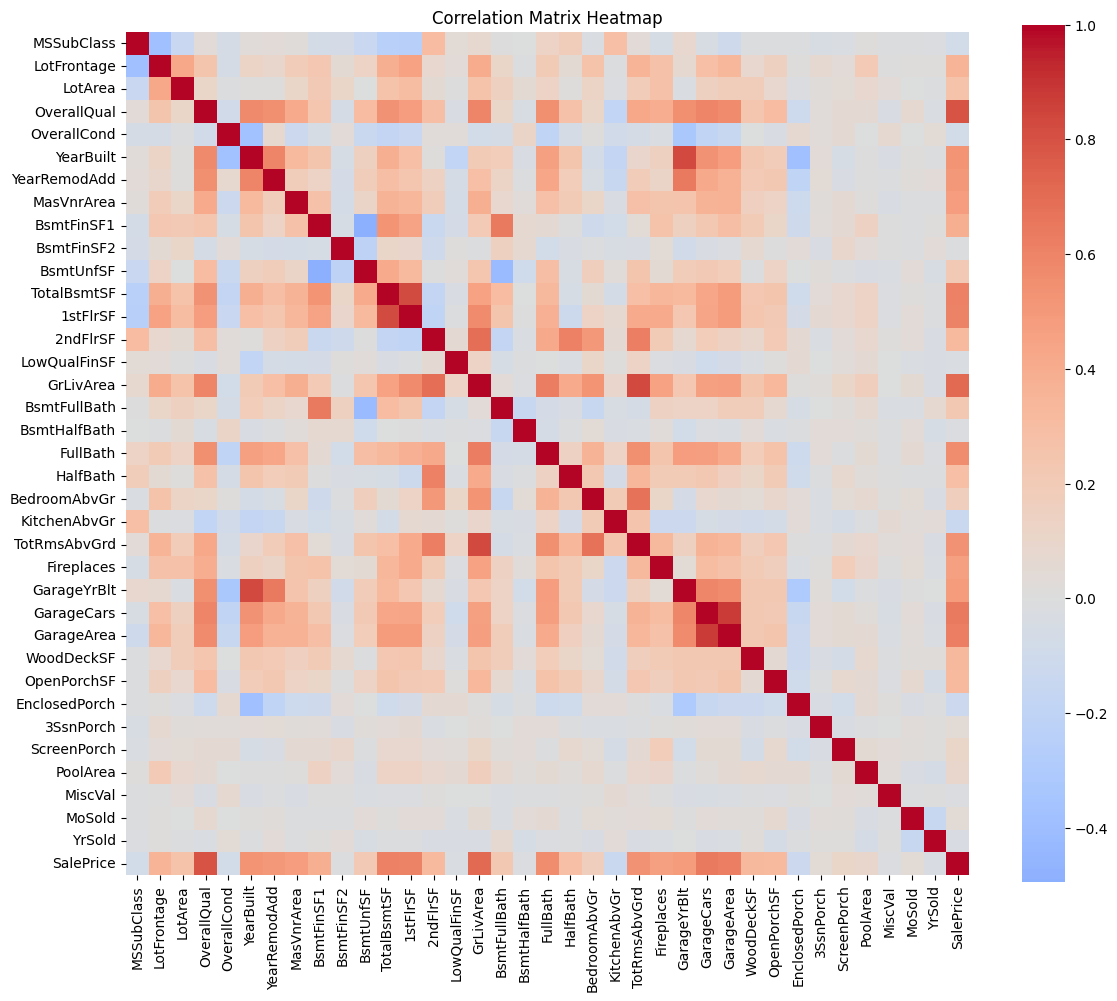

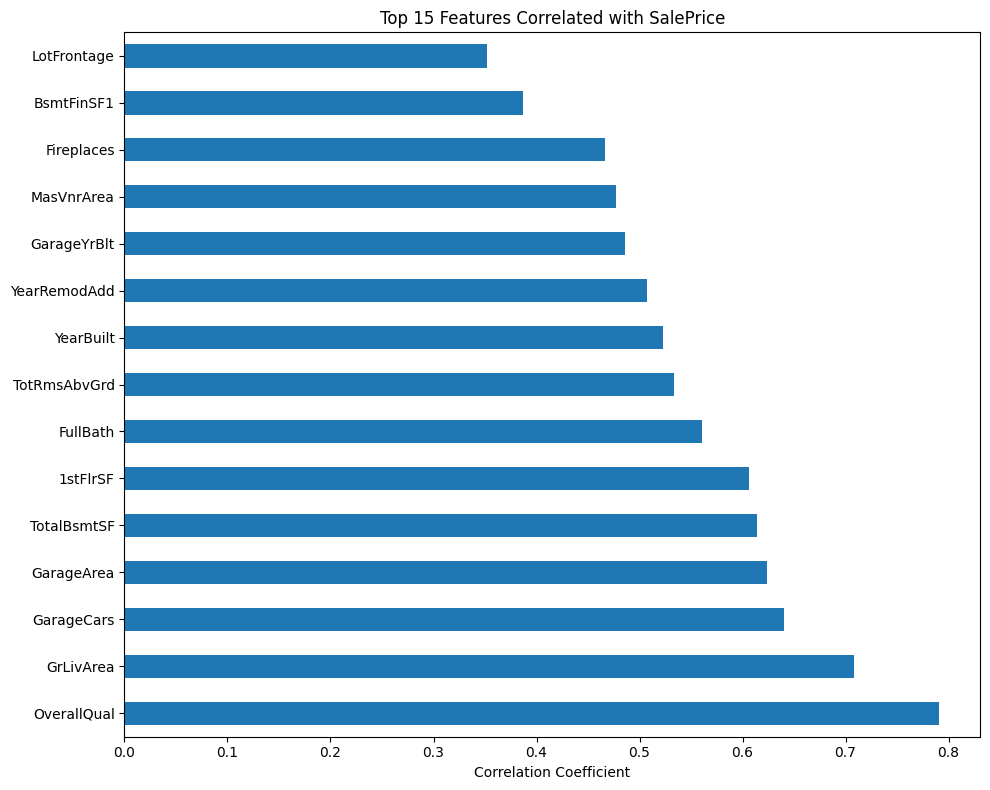

In [55]:
# CORRELATION ANALYSIS
import seaborn as sns

print("CORRELATION ANALYSIS")

# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_cols if col != 'SalePrice']

# Calculate correlations with SalePrice
correlations = df[numerical_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print("Top 15 correlations with SalePrice:")
print(correlations.head(16))  # Include SalePrice itself

# Create correlation matrix heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features + ['SalePrice']].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, 
            annot=False,  # Don't show numbers (too many features)
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Plot top correlations with SalePrice
plt.figure(figsize=(10, 8))
top_correlations = correlations[1:16]  # Exclude SalePrice itself, top 15
top_correlations.plot(kind='barh')
plt.title('Top 15 Features Correlated with SalePrice')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


In [56]:
# Handle Missing Values - Corrected Approach

print("=== HANDLING MISSING VALUES (CORRECTED) ===")

# Handle numerical features where missing = 0
numerical_features_to_fill = ['MasVnrArea', 'LotFrontage', 'GarageYrBlt']

print("Numerical features to fill with 0:")
for feature in numerical_features_to_fill:
    print(f"- {feature}")

# Handle numerical features (missing = 0)
print("\n=== NUMERICAL FEATURES (Fill with 0) ===")
for col in numerical_features_to_fill:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            df[col].fillna(0, inplace=True)
            print(f"✓ Filled {col}: {missing_count} missing values with 0")
        else:
            print(f"✓ {col}: No missing values")

# Check remaining missing values in numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'SalePrice']
remaining_missing = df[numerical_cols].isnull().sum().sum()
print(f"\n=== NUMERICAL COLUMNS STATUS ===")
print(f"Remaining missing values in numerical columns: {remaining_missing}")

if remaining_missing > 0:
    print("Numerical columns with remaining missing values:")
    for col in numerical_cols:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            print(f"  {col}: {missing_count} missing values (keeping as-is)")

# Categorical columns - leave missing values as is for get_dummies
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n=== CATEGORICAL COLUMNS (Keep NaN for get_dummies) ===")
print(f"Total categorical columns: {len(categorical_cols)}")
categorical_missing = 0
for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        categorical_missing += missing_count
        print(f"  {col}: {missing_count} missing values (keeping as NaN)")

print(f"\nTotal categorical missing values preserved: {categorical_missing}")

print("\n=== MISSING VALUE STRATEGY SUMMARY ===")
print("✓ Numerical features (MasVnrArea, LotFrontage, GarageYrBlt): Filled with 0")
print("✓ All other numerical features: Should now have no missing values")
print("✓ Categorical features: Preserved NaN for get_dummies (will create separate dummy columns)")
print("✓ Simple and clean approach - NA becomes 0 for numerical measurements")


=== HANDLING MISSING VALUES (CORRECTED) ===
Numerical features to fill with 0:
- MasVnrArea
- LotFrontage
- GarageYrBlt

=== NUMERICAL FEATURES (Fill with 0) ===
✓ Filled MasVnrArea: 8 missing values with 0
✓ Filled LotFrontage: 259 missing values with 0
✓ Filled GarageYrBlt: 81 missing values with 0

=== NUMERICAL COLUMNS STATUS ===
Remaining missing values in numerical columns: 0

=== CATEGORICAL COLUMNS (Keep NaN for get_dummies) ===
Total categorical columns: 43
  Alley: 1369 missing values (keeping as NaN)
  MasVnrType: 872 missing values (keeping as NaN)
  BsmtQual: 37 missing values (keeping as NaN)
  BsmtCond: 37 missing values (keeping as NaN)
  BsmtExposure: 38 missing values (keeping as NaN)
  BsmtFinType1: 37 missing values (keeping as NaN)
  BsmtFinType2: 38 missing values (keeping as NaN)
  Electrical: 1 missing values (keeping as NaN)
  FireplaceQu: 690 missing values (keeping as NaN)
  GarageType: 81 missing values (keeping as NaN)
  GarageFinish: 81 missing values (kee

/var/folders/jy/dj2qldqs07x6xd7jbmjb90y00000gn/T/ipykernel_4402/2347945561.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)


In [57]:
# Handle Missing Values - Corrected Approach
from sklearn.impute import KNNImputer

print("=== HANDLING MISSING VALUES (CORRECTED) ===")

# Categorize numerical columns by missing value meaning
structural_features = ['MasVnrArea']  # Missing = feature doesn't exist (no masonry veneer)
measurement_features = ['LotFrontage', 'GarageYrBlt']  # Missing = measurement not recorded

print("Feature categorization:")
print(f"Structural features (missing = doesn't exist): {structural_features}")
print(f"Measurement features (missing = not recorded): {measurement_features}")

# Handle structural features (missing = feature doesn't exist)
print("\n=== STRUCTURAL FEATURES (Fill with 0) ===")
for col in structural_features:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            df[col].fillna(0, inplace=True)
            print(f"Filled {col}: {missing_count} missing values with 0 (no feature)")
        else:
            print(f"{col}: No missing values")


# Check remaining missing values in numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'SalePrice']
remaining_missing = df[numerical_cols].isnull().sum().sum()
print(f"\nRemaining missing values in numerical columns: {remaining_missing}")

# Categorical columns - leave missing values as is for get_dummies
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n=== CATEGORICAL COLUMNS (Keep NaN for get_dummies) ===")
print(f"Total categorical columns: {len(categorical_cols)}")
categorical_missing = 0
for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        categorical_missing += missing_count
        print(f"{col}: {missing_count} missing values (keeping as NaN)")

print(f"\nTotal categorical missing values preserved: {categorical_missing}")

print("\n=== MISSING VALUE STRATEGY SUMMARY ===")
print("✓ Structural features (MasVnrArea): Filled with 0 (feature doesn't exist)")
print("✓ Measurement features (LotFrontage, GarageYrBlt): KNN imputed (measurement error)")
print("✓ Categorical features: Preserved NaN for get_dummies (will create separate dummy columns)")
print("✓ No false information created by inappropriate imputation")

# Handle Missing Values - Corrected Approach

print("=== HANDLING MISSING VALUES (CORRECTED) ===")

# Only handle structural features where missing clearly means "doesn't exist"
structural_features = ['MasVnrArea']  # Missing = no masonry veneer, so area = 0

print("Structural features (missing = doesn't exist):")
print(f"- {structural_features}")

# Handle structural features (missing = feature doesn't exist)
print("\n=== STRUCTURAL FEATURES (Fill with 0) ===")
for col in structural_features:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            df[col].fillna(0, inplace=True)
            print(f"✓ Filled {col}: {missing_count} missing values with 0 (no masonry veneer)")
        else:
            print(f"✓ {col}: No missing values")

# Check remaining missing values in numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'SalePrice']
remaining_missing = df[numerical_cols].isnull().sum().sum()
print(f"\n=== NUMERICAL COLUMNS STATUS ===")
print(f"Remaining missing values in numerical columns: {remaining_missing}")

if remaining_missing > 0:
    print("Numerical columns with remaining missing values:")
    for col in numerical_cols:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            print(f"  {col}: {missing_count} missing values (keeping as-is)")

# Categorical columns - leave missing values as is for get_dummies
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n=== CATEGORICAL COLUMNS (Keep NaN for get_dummies) ===")
print(f"Total categorical columns: {len(categorical_cols)}")
categorical_missing = 0
for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        categorical_missing += missing_count
        print(f"  {col}: {missing_count} missing values (keeping as NaN)")

print(f"\nTotal categorical missing values preserved: {categorical_missing}")

print("\n=== MISSING VALUE STRATEGY SUMMARY ===")
print("✓ Structural features (MasVnrArea): Filled with 0 (feature doesn't exist)")
print("✓ All other numerical features: Keep missing as-is (meaningful missingness)")
print("✓ Categorical features: Preserved NaN for get_dummies (will create separate dummy columns)")
print("✓ No artificial imputation - preserves data integrity")

=== HANDLING MISSING VALUES (CORRECTED) ===
Feature categorization:
Structural features (missing = doesn't exist): ['MasVnrArea']
Measurement features (missing = not recorded): ['LotFrontage', 'GarageYrBlt']

=== STRUCTURAL FEATURES (Fill with 0) ===
MasVnrArea: No missing values

Remaining missing values in numerical columns: 0

=== CATEGORICAL COLUMNS (Keep NaN for get_dummies) ===
Total categorical columns: 43
Alley: 1369 missing values (keeping as NaN)
MasVnrType: 872 missing values (keeping as NaN)
BsmtQual: 37 missing values (keeping as NaN)
BsmtCond: 37 missing values (keeping as NaN)
BsmtExposure: 38 missing values (keeping as NaN)
BsmtFinType1: 37 missing values (keeping as NaN)
BsmtFinType2: 38 missing values (keeping as NaN)
Electrical: 1 missing values (keeping as NaN)
FireplaceQu: 690 missing values (keeping as NaN)
GarageType: 81 missing values (keeping as NaN)
GarageFinish: 81 missing values (keeping as NaN)
GarageQual: 81 missing values (keeping as NaN)
GarageCond: 81 m

In [58]:
# Encode categorical columns - Updated approach
print("=== ENCODING CATEGORICAL VARIABLES ===")

# Use get_dummies with proper parameters
X = pd.get_dummies(df.drop(columns=['SalePrice']), 
                   dtype=int,  # This ensures 1s and 0s instead of True/False
                   dummy_na=False,  # This creates dummy variables for NaN values
                   drop_first=False)  # Keep all categories for now

y = df['SalePrice']


=== ENCODING CATEGORICAL VARIABLES ===


In [59]:
# FEATURE ENGINEERING - COLUMN MERGING
print("=== FEATURE ENGINEERING - COLUMN MERGING ===")

# 1. Separate Square Footage Components (more granular information)
df['TotalAboveGradeSF'] = df['1stFlrSF'] + df['2ndFlrSF']
print("Created TotalAboveGradeSF (1stFlrSF + 2ndFlrSF)")
print("Created TotalBsmtSF_Feature (basement square footage separate)")

# 2. Separate Full and Half Bathrooms (more granular information)
df['TotalFullBaths'] = df['FullBath'] + df['BsmtFullBath']
df['TotalHalfBaths'] = df['HalfBath'] + df['BsmtHalfBath']

# 3. Total Porch Area
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + 
                     df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF'])

# 4. House Age Features
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)



=== FEATURE ENGINEERING - COLUMN MERGING ===
Created TotalAboveGradeSF (1stFlrSF + 2ndFlrSF)
Created TotalBsmtSF_Feature (basement square footage separate)
